In [6]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

%matplotlib inline

In [3]:
jsondir = "../results/angiosperm"
models = ["SVC", "RF", "MLP", "KNN", "HGB"]
metrics = ["accuracy", "precision", "recall", "f1_score", "confusion_matrix"]

conf_mats = dict()
model_dfs = dict()
for m in models:
    conf_mats[m] = dict()
    jsonfname = f"{jsondir}/{m}_performance.json"
    with open(jsonfname, "r") as fp:
        perfdict = json.load(fp)

    for k in perfdict.keys():
        conf_mats[m][k] = perfdict[k]["confusion_matrix"]
        del perfdict[k]["confusion_matrix"]

    model_dfs[m] = pd.DataFrame(perfdict)

# print(model_dfs)


In [7]:
cm_angio = ConfusionMatrixDisplay(np.asarray(conf_mats['KNN']['angiosperm']),
                                  display_labels=["Above", "Below", "Other", "WholePlant"])
cm_arabi = ConfusionMatrixDisplay(np.asarray(conf_mats['KNN']['arabidopsis']),
                                  display_labels=["Above", "Below", "Other", "WholePlant"])

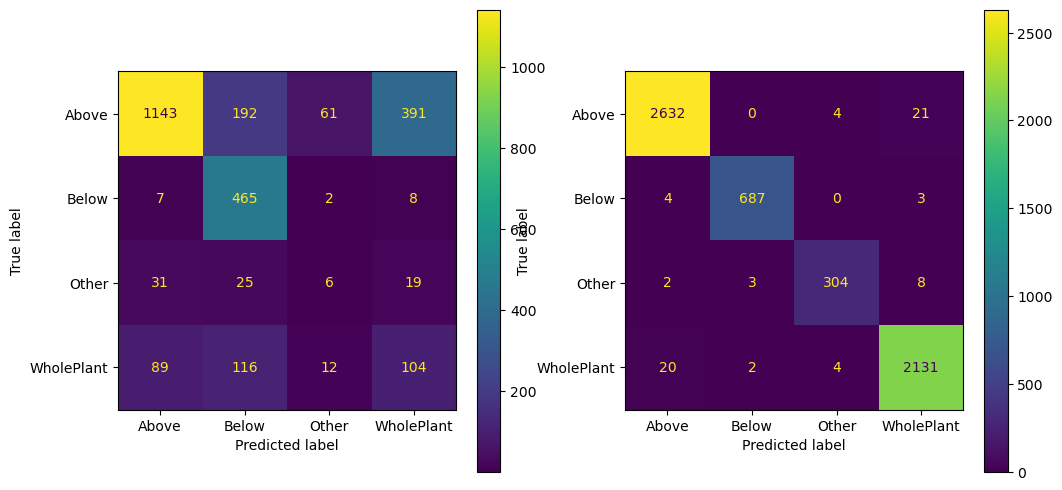

In [11]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
cm_angio.plot(ax=axs[0])
cm_arabi.plot(ax=axs[1])

In [14]:
jsondir2 = "../results/arabidopsis"
conf_mats2 = dict()
model_dfs2 = dict()
for m in models:
    jsonfname = f"{jsondir2}/{m}_performance.json"
    with open(jsonfname, "r") as fp:
        perfdict = json.load(fp)

    conf_mats2[m] = perfdict["confusion_matrix"]
    del perfdict["confusion_matrix"]
    model_dfs2[m] = perfdict

df = pd.DataFrame(model_dfs2)
print(df)


                SVC        RF       MLP       KNN       HGB
accuracy   0.798798  0.828498  0.847897  0.989185  0.977511
precision  0.762420  0.846328  0.844941  0.989210  0.977647
recall     0.798798  0.828498  0.847897  0.989185  0.977511
f1_score   0.775367  0.835077  0.844024  0.989193  0.977304
